# Spooky Author Identification — methodology 2: stylometry and latent topics with gradient-boosted trees

Methodology 1 reads a sentence as a bag of n-grams. Stylometry asks a different question: *how* does an author write, independently of *what* is
being described? This model sees only **hand-built style statistics** and **latent topics**, never raw n-grams:

| Group | Features |
|---|---|
| Length and word shape | characters, words, mean/std/max word length, type–token ratio, share of long words, word-length histogram (1…12+) |
| Punctuation habit | commas, semicolons, colons, periods, `!`, `?`, hyphens, dashes, apostrophes, quotes, parentheses, digits per 100 characters |
| Capitalisation | upper-case share, capitalised words, all-caps words, starts upper-case, ends with punctuation |
| Letter frequencies | 26 relative letter frequencies |
| Function words | relative frequencies of 156 stop words and archaic function words (*thou, hath, upon, whilst, …*) |
| Latent topics | 100 components of a truncated SVD of word 1–2-gram TF-IDF (fitted on each fold's training rows) |

The classifier is LightGBM (multiclass, softmax). Early stopping uses an inner 10% of each fold's training rows; the outer validation fold is only *watched*
(log loss every 10 trees) and never selects anything. Probabilities are temperature-scaled with $T$ fitted on the other folds' out-of-fold predictions, as for every methodology.

In [1]:
import time, json, os
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import lightgbm as lgb
from concurrent.futures import ThreadPoolExecutor
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score
from sklearn.calibration import calibration_curve
import spooky_common as S, spooky_style as ST
sns.set_theme(style="whitegrid"); plt.rcParams["figure.dpi"] = 110
PAL = ["#4C72B0", "#C44E52", "#55A868"]; AU = S.AUTHORS; os.makedirs("assets", exist_ok=True)
train, test, folds, y = S.load(); vocab = ST.function_word_vocab(list(train.text) + list(test.text))
Fa, Ft = ST.style_features(train.text, vocab), ST.style_features(test.text, vocab); print("stylometric features:", Fa.shape[1], "| function words:", len(vocab))

stylometric features: 221 | function words: 156


## 1. What distinguishes the authors on the surface

Distributions of a few style statistics per author (training sentences). Semicolons and commas are the classic stylometric tell: Shelley uses far more semicolons.

/tmp/ipykernel_238947/1503428494.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=d, x="author", y="v", order=AU, palette=PAL, ax=ax, showfliers=False); ax.set_title(c); ax.set_xlabel(""); ax.set_ylabel("")
/tmp/ipykernel_238947/1503428494.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=d, x="author", y="v", order=AU, palette=PAL, ax=ax, showfliers=False); ax.set_title(c); ax.set_xlabel(""); ax.set_ylabel("")


/tmp/ipykernel_238947/1503428494.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=d, x="author", y="v", order=AU, palette=PAL, ax=ax, showfliers=False); ax.set_title(c); ax.set_xlabel(""); ax.set_ylabel("")
/tmp/ipykernel_238947/1503428494.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=d, x="author", y="v", order=AU, palette=PAL, ax=ax, showfliers=False); ax.set_title(c); ax.set_xlabel(""); ax.set_ylabel("")
/tmp/ipykernel_238947/1503428494.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=d, x="author", y="v", order

/tmp/ipykernel_238947/1503428494.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=d, x="author", y="v", order=AU, palette=PAL, ax=ax, showfliers=False); ax.set_title(c); ax.set_xlabel(""); ax.set_ylabel("")
/tmp/ipykernel_238947/1503428494.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=d, x="author", y="v", order=AU, palette=PAL, ax=ax, showfliers=False); ax.set_title(c); ax.set_xlabel(""); ax.set_ylabel("")
/tmp/ipykernel_238947/1503428494.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=d, x="author", y="v", order

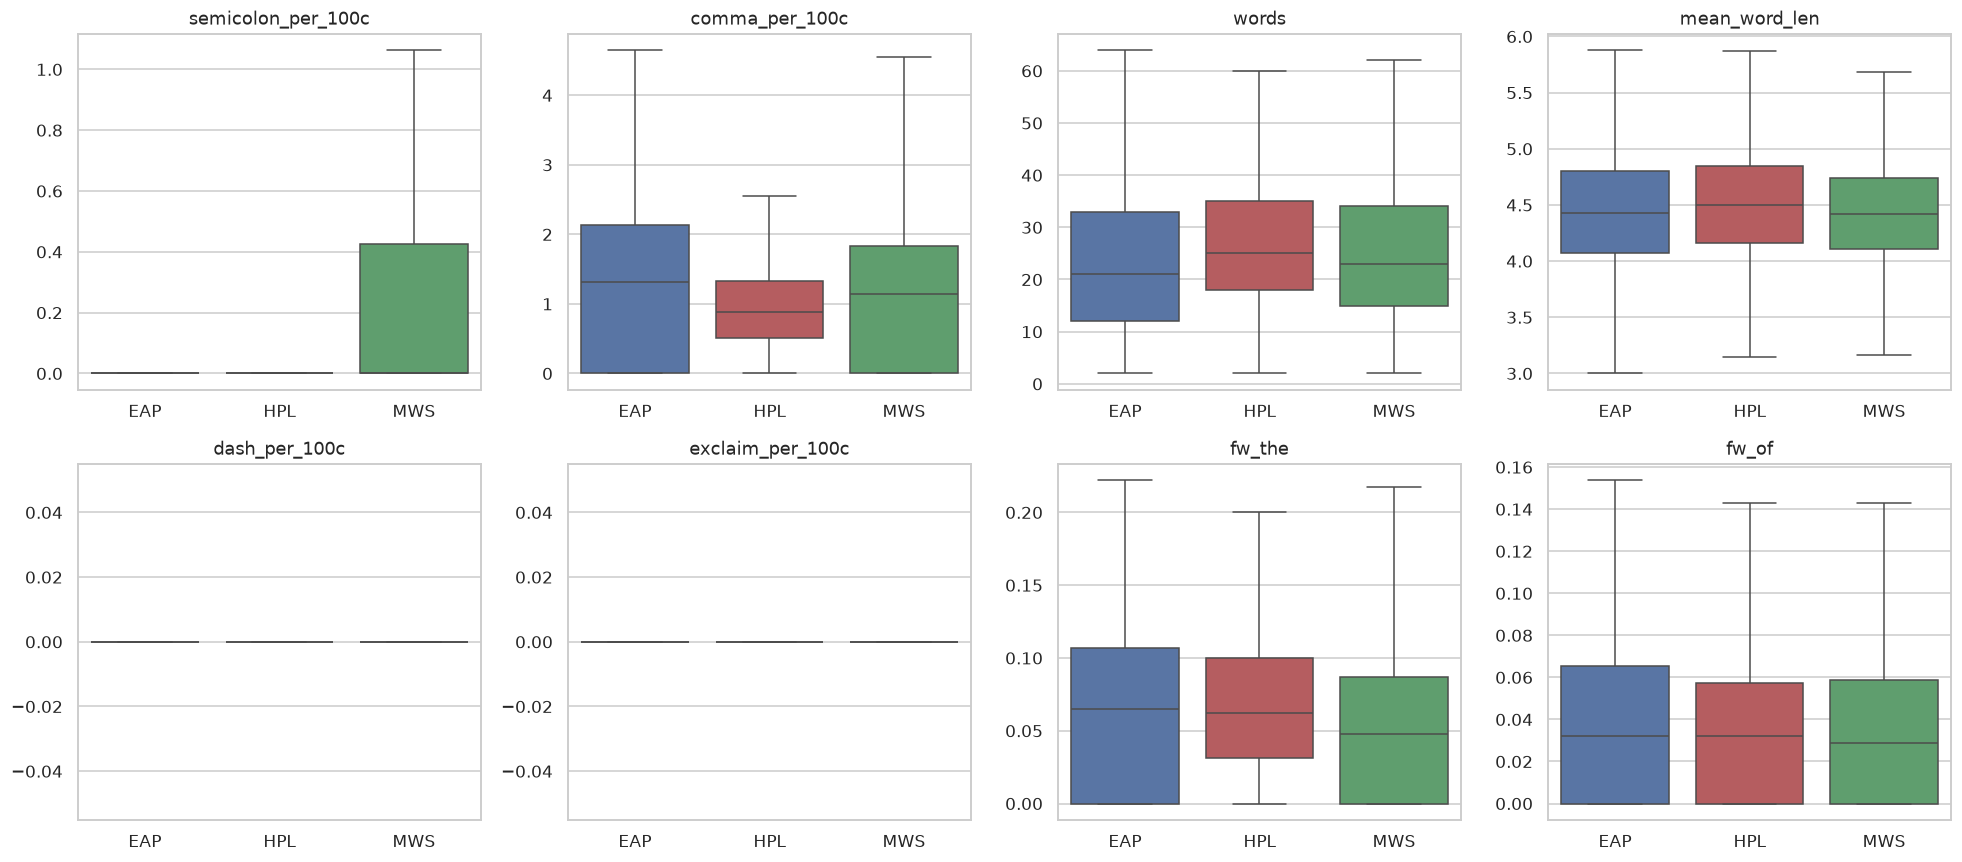

author,EAP,HPL,MWS,spread
fw_her,0.0025,0.0007,0.0096,0.4814
semicolons,0.1714,0.2028,0.4404,0.4545
semicolon_per_100c,0.0966,0.1021,0.2516,0.4490
fw_my,0.0094,0.0063,0.0169,0.3942
comma_per_100c,1.4029,0.9899,1.2341,0.3781
fw_she,0.0017,0.0005,0.0057,0.3712
commas_per_word,0.0790,0.0558,0.0690,0.3708
wl_2,0.1842,0.1545,0.1765,0.3499


In [2]:
cols = ["semicolon_per_100c", "comma_per_100c", "words", "mean_word_len", "dash_per_100c", "exclaim_per_100c", "fw_the", "fw_of"]
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, c in zip(axes.ravel(), cols):
    d = pd.DataFrame({"v": Fa[c], "author": train.author}); d = d[d.v <= d.v.quantile(0.99)] if c not in ("semicolon_per_100c",) else d[d.v <= 1.5]
    sns.boxplot(data=d, x="author", y="v", order=AU, palette=PAL, ax=ax, showfliers=False); ax.set_title(c); ax.set_xlabel(""); ax.set_ylabel("")
plt.tight_layout(); plt.savefig("assets/style_01_author_style_distributions.png", bbox_inches="tight"); plt.show()
means = Fa.groupby(train.author).mean().T; means["spread"] = (means.max(axis=1) - means.min(axis=1)) / (Fa.std() + 1e-9); display(means.sort_values("spread", ascending=False).head(8).round(4))

## 2. Training (per-iteration statistics only; figures drawn afterwards)

Training is done by `train_style.py`: five folds × two variants (with and without the latent topics), each fit in its own process and saved on completion
(per-iteration inner log loss, the watched outer-fold loss every 10 trees, split gains, predictions, the booster). This notebook assembles the saved fits; nothing is retrained here.

In [3]:
import train_style as TS, lightgbm as lgb
full, sty = TS.load_runs("full"), TS.load_runs("style"); assert full and sty, "run train_style.py first"
for r in full: r["names"] = [str(n) for n in r["names"]]; r["gain"] = pd.Series(r["gain"], index=r["names"]); r["V"] = np.load(f"cache/style_full_V{r['k']}.npy"); r["model"] = lgb.Booster(model_file=f"checkpoints/style_full_f{r['k']}.txt")

def collect(res):
    oof = np.zeros((len(y), 3)); tst = 0
    for r in res: oof[r["va"]] = r["pv"]; tst = tst + r["pt"] / 5
    return oof, tst
oof_f, tst_f = collect(full); oof_s, tst_s = collect(sty); print(f"best iterations (with topics): {[int(r['best']) for r in full]}, (style only): {[int(r['best']) for r in sty]}")
cal_f, Ts, tcal_f = S.cv_temperature(oof_f, y, folds, tst_f); cal_s, _, _ = S.cv_temperature(oof_s, y, folds)
ev_f, ev_raw = S.evaluate(y, cal_f, folds), S.evaluate(y, oof_f, folds); ev_s = S.evaluate(y, cal_s, folds, 200)
print(f"stylometry + topics: log loss {ev_f['log_loss']:.4f} {np.round(ev_f['log_loss_ci95'], 4)} (raw {ev_raw['log_loss']:.4f}), accuracy {ev_f['accuracy']:.4f}, macro-F1 {ev_f['macro_f1']:.4f}")
print(f"stylometry only    : log loss {ev_s['log_loss']:.4f}, accuracy {ev_s['accuracy']:.4f}")
S.save_method("style_gbdt", cal_f, tcal_f, dict(method="stylometric features + latent topics, LightGBM", best_iterations=[int(r["best"]) for r in full], temperature_per_fold=Ts, raw=ev_raw, ablation_style_only=ev_s, **ev_f))

best iterations (with topics): [806, 989, 872, 989, 1238], (style only): [781, 803, 819, 678, 756]


stylometry + topics: log loss 0.6276 [0.617  0.6375] (raw 0.6279), accuracy 0.7355, macro-F1 0.7331
stylometry only    : log loss 0.6956, accuracy 0.7004


## 3. In-training statistics

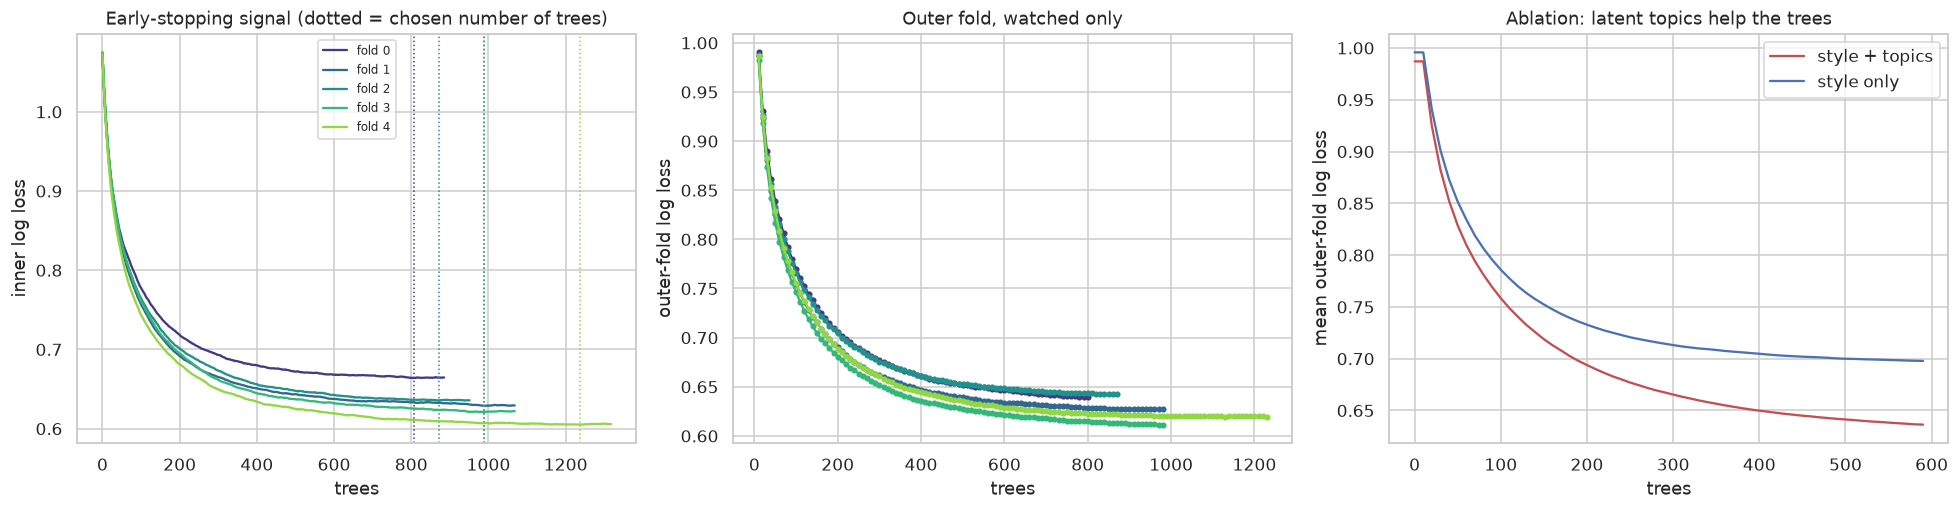

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.8)); cs = sns.color_palette("viridis", 5)
for r in full:
    axes[0].plot(r["inner"], color=cs[r["k"]], label=f"fold {r['k']}"); axes[0].axvline(int(r["best"]), color=cs[r["k"]], ls=":", lw=1); it, ll = zip(*r["mon"]); axes[1].plot(it, ll, "o-", color=cs[r["k"]], ms=3)
axes[0].set_xlabel("trees"); axes[0].set_ylabel("inner log loss"); axes[0].set_title("Early-stopping signal (dotted = chosen number of trees)"); axes[0].legend(fontsize=8)
axes[1].set_xlabel("trees"); axes[1].set_ylabel("outer-fold log loss"); axes[1].set_title("Outer fold, watched only")
for res, lab, c in [(full, "style + topics", "#C44E52"), (sty, "style only", "#4C72B0")]:
    m_ = np.mean([np.interp(np.arange(0, 600, 10), *map(np.array, zip(*r["mon"]))) for r in res], axis=0); axes[2].plot(np.arange(0, 600, 10), m_, color=c, label=lab)
axes[2].set_xlabel("trees"); axes[2].set_ylabel("mean outer-fold log loss"); axes[2].legend(); axes[2].set_title("Ablation: latent topics help the trees")
plt.tight_layout(); plt.savefig("assets/style_02_training_curves.png", bbox_inches="tight"); plt.show()

## 4. Post-training diagnostics

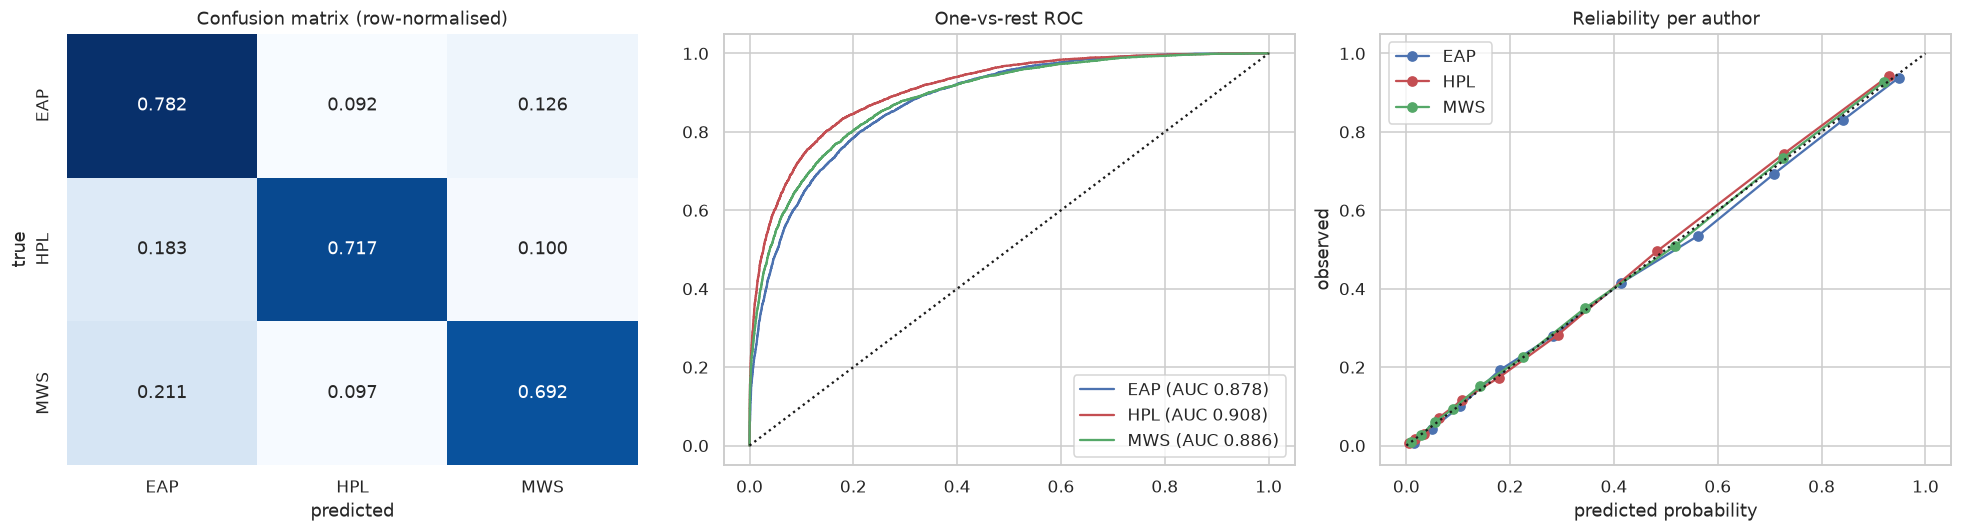

In [5]:
pred = cal_f.argmax(1); fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.heatmap(confusion_matrix(y, pred, normalize="true"), annot=True, fmt=".3f", cmap="Blues", ax=axes[0], cbar=False, xticklabels=AU, yticklabels=AU); axes[0].set_xlabel("predicted"); axes[0].set_ylabel("true"); axes[0].set_title("Confusion matrix (row-normalised)")
for c in range(3):
    f, t, _ = roc_curve(y == c, cal_f[:, c]); axes[1].plot(f, t, color=PAL[c], label=f"{AU[c]} (AUC {roc_auc_score(y == c, cal_f[:, c]):.3f})")
axes[1].plot([0, 1], [0, 1], "k:"); axes[1].legend(); axes[1].set_title("One-vs-rest ROC")
for c in range(3):
    fp, mp = calibration_curve(y == c, cal_f[:, c], n_bins=10, strategy="quantile"); axes[2].plot(mp, fp, "o-", color=PAL[c], label=AU[c])
axes[2].plot([0, 1], [0, 1], "k:"); axes[2].set_xlabel("predicted probability"); axes[2].set_ylabel("observed"); axes[2].legend(); axes[2].set_title("Reliability per author")
plt.tight_layout(); plt.savefig("assets/style_03_post_training_diagnostics.png", bbox_inches="tight"); plt.show()

### What the trees use: split gain and SHAP

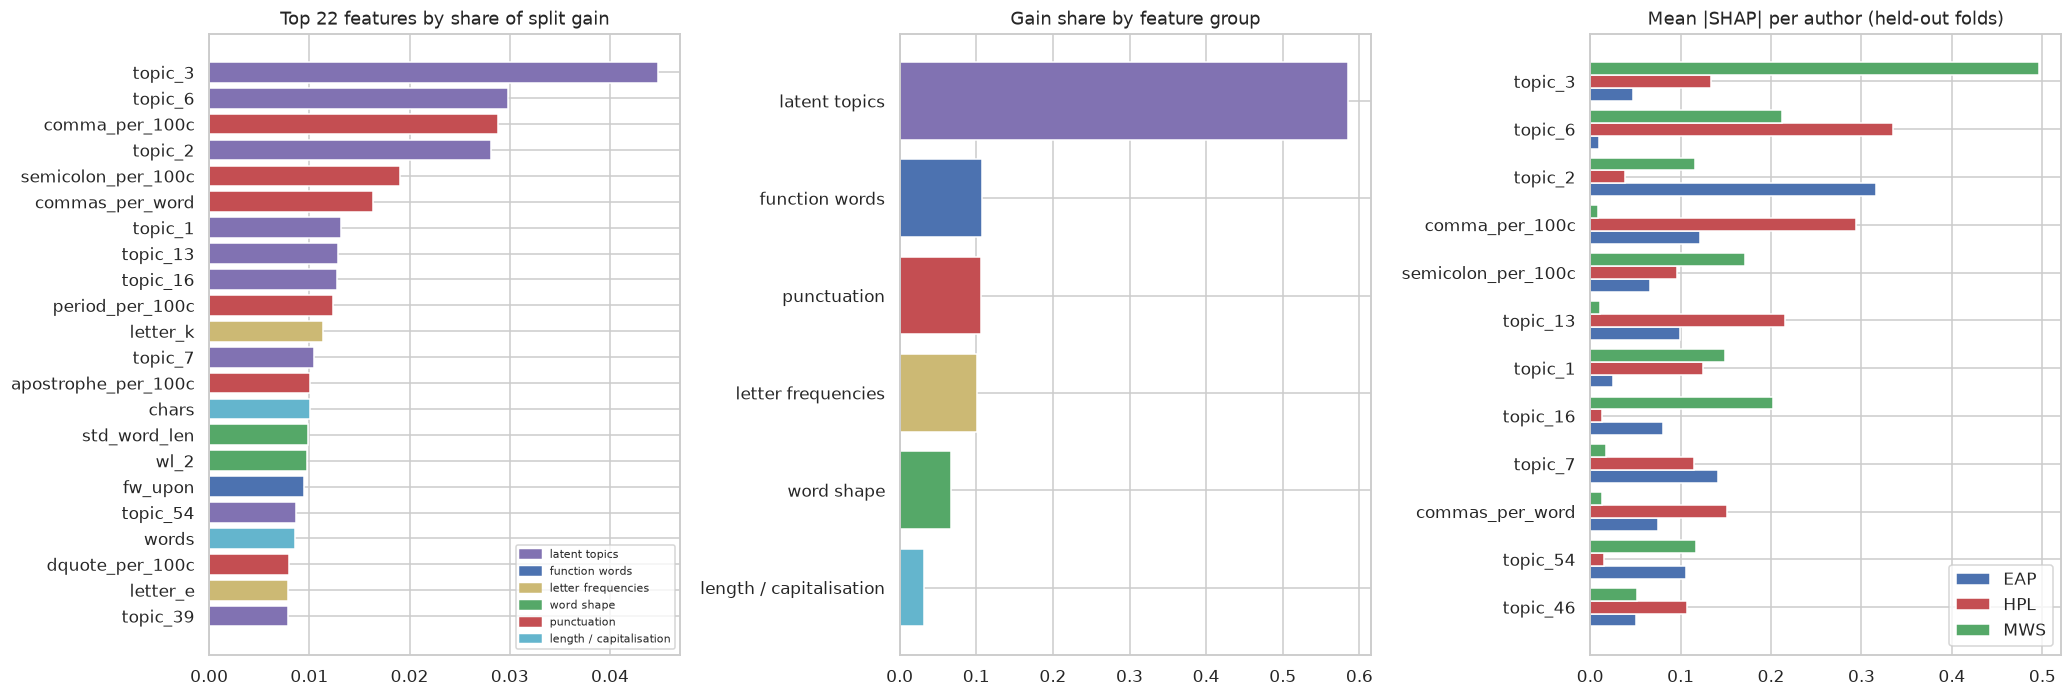

{'length / capitalisation': 0.032, 'word shape': 0.067, 'letter frequencies': 0.101, 'punctuation': 0.106, 'function words': 0.107, 'latent topics': 0.586}


In [6]:
G = pd.concat([r["gain"] for r in full], axis=1).mean(axis=1); G = G / G.sum()
def group(n):
    if n.startswith("topic_"): return "latent topics"
    if n.startswith("fw_"): return "function words"
    if n.startswith("letter_"): return "letter frequencies"
    if n.startswith("wl_") or "word_len" in n or n in ("chars_per_word", "long_words_frac", "type_token"): return "word shape"
    if "per_100c" in n or n in ("semicolons", "commas_per_word"): return "punctuation"
    return "length / capitalisation"
GC = {"latent topics": "#8172B2", "function words": "#4C72B0", "letter frequencies": "#CCB974", "word shape": "#55A868", "punctuation": "#C44E52", "length / capitalisation": "#64B5CD"}
fig, axes = plt.subplots(1, 3, figsize=(19, 6.5)); top = G.sort_values().tail(22)
axes[0].barh(top.index, top.values, color=[GC[group(n)] for n in top.index]); axes[0].set_title("Top 22 features by share of split gain"); axes[0].legend(handles=[plt.Rectangle((0, 0), 1, 1, color=c) for c in GC.values()], labels=list(GC), fontsize=7, loc="lower right")
gg = G.groupby([group(n) for n in G.index]).sum().sort_values(); axes[1].barh(gg.index, gg.values, color=[GC[n] for n in gg.index]); axes[1].set_title("Gain share by feature group")
Vall = np.vstack([r["V"] for r in full]); F_ = len(full[0]["names"]); sh = np.vstack([r["model"].predict(r["V"], pred_contrib=True) for r in full])
msh = np.stack([np.abs(sh[:, c * (F_ + 1):(c + 1) * (F_ + 1) - 1]).mean(0) for c in range(3)], 1); order = np.argsort(-msh.sum(1))[:12][::-1]; w = 0.27
for c in range(3): axes[2].barh(np.arange(12) + (c - 1) * w, msh[order, c], height=w, color=PAL[c], label=AU[c])
axes[2].set_yticks(range(12), [full[0]["names"][i] for i in order]); axes[2].set_title("Mean |SHAP| per author (held-out folds)"); axes[2].legend()
plt.tight_layout(); plt.savefig("assets/style_04_feature_use.png", bbox_inches="tight"); plt.show()
print({g: round(float(v), 3) for g, v in gg.items()})